In [1]:
# =====================================================================
# STEP 1: INPUT INFRASTRUCTURE (GENERATING THE RAW CHAOTIC MATRIX)
# =====================================================================
import pandas as pd
import numpy as np

# Set seed for strict mathematical replication
np.random.seed(42)
n_rows = 1000

# Synthesize basic feature distributions
experience = np.random.gamma(shape=2, scale=3, size=n_rows)
certifications = experience * 0.85 + np.random.normal(0, 0.5, n_rows) # Engineered collinearity
certifications = np.clip(certifications, 0, 10)
hours = np.random.normal(loc=160, scale=15, size=n_rows)

# Inject intentional anomalies and transcription errors (Outliers)
outlier_indices = np.random.choice(n_rows, size=30, replace=False)
hours[outlier_indices[:15]] = hours[outlier_indices[:15]] * 5  # Severe upper anomalies
hours[outlier_indices[15:]] = -50                             # Severe lower anomalies

# Generate categorical baseline and the dependent target label (y)
depts = np.random.choice(['London', 'Paris', 'Tokyo'], size=n_rows, p=[0.4, 0.3, 0.3])
target = (experience * 5) + (hours * 0.1) + np.random.normal(0, 10, n_rows)

# Inject controlled missingness boundaries to trigger the Decision Matrix
mask_exp = np.random.rand(n_rows) < 0.08      # ~8% missing (Triggers Median Imputation)
mask_hours = np.random.rand(n_rows) < 0.25    # ~25% missing (Triggers KNN Imputation)
mask_dept = np.random.rand(n_rows) < 0.03     # ~3% missing (Triggers Listwise Row Deletion)

experience[mask_exp] = np.nan
hours[mask_hours] = np.nan
depts = np.where(mask_dept, None, depts)

# Build Raw DataFrame
df = pd.DataFrame({
    'Experience_Years': experience,
    'Certifications': certifications,
    'Monthly_Hours': hours,
    'Department': depts,
    'Performance_Score': target
})

print("--- [DECODELABS SYSTEM NOTICE]: RAW MESSY MATRIX INITIALIZED ---")
print(f"Matrix Dimension Profile: {df.shape[0]} rows x {df.shape[1]} columns")
print("\nMissing Values Audit:")
print(df.isnull().sum())

--- [DECODELABS SYSTEM NOTICE]: RAW MESSY MATRIX INITIALIZED ---
Matrix Dimension Profile: 1000 rows x 5 columns

Missing Values Audit:
Experience_Years      84
Certifications         0
Monthly_Hours        255
Department            41
Performance_Score      0
dtype: int64


In [2]:
# =====================================================================
# STEP 2: PROCESS STAGE (PART A) - RESOLVING MATRIX HOLES
# =====================================================================
from sklearn.impute import KNNImputer

print("--- [RESOLVING MISSING DATA VIA DECISION MATRIX] ---")

# Rule 1: Sparse Missingness (< 5%) -> Execute Listwise Row Deletion
df = df.dropna(subset=['Department'])
print("-> Step Completed: Dropped sparse rows (<5% missingness) for 'Department'.")

# Rule 2: Skewed Missingness (5% to 20%) -> Execute Global Median Imputation
median_exp = df['Experience_Years'].median()
df['Experience_Years'] = df['Experience_Years'].fillna(median_exp)
print(f"-> Step Completed: Imputed 'Experience_Years' via Global Median ({median_exp:.2f}).")

# Rule 3: Dense Missingness (> 20%) -> Execute Multi-Dimensional KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5)
numeric_features = ['Experience_Years', 'Certifications', 'Monthly_Hours']
df[numeric_features] = knn_imputer.fit_transform(df[numeric_features])
print("-> Step Completed: Imputed 'Monthly_Hours' via 5-Nearest Neighbors Imputer.")

print("\nMissing Values Verification Check (Should all be 0):")
print(df[['Department', 'Experience_Years', 'Monthly_Hours']].isnull().sum())

--- [RESOLVING MISSING DATA VIA DECISION MATRIX] ---
-> Step Completed: Dropped sparse rows (<5% missingness) for 'Department'.
-> Step Completed: Imputed 'Experience_Years' via Global Median (5.19).
-> Step Completed: Imputed 'Monthly_Hours' via 5-Nearest Neighbors Imputer.

Missing Values Verification Check (Should all be 0):
Department          0
Experience_Years    0
Monthly_Hours       0
dtype: int64


--- [NEUTRALIZING EXTREME DISTORTIONS VIA IQR] ---
Calculated Statistical Fences: Lower Bound = 123.74, Upper Bound = 195.27
-> Step Completed: Extreme anomalies successfully neutralized via Winsorization Capping.


In [6]:
# =====================================================================
# STEP 3: PROCESS STAGE (PART B) - INTERQUARTILE RANGE (IQR) CAPPING
# =====================================================================
print("--- [NEUTRALIZING EXTREME DISTORTIONS VIA IQR] ---")

# Step 1: Isolate Upper and Lower Quantiles
Q1 = df['Monthly_Hours'].quantile(0.25)
Q3 = df['Monthly_Hours'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Set Strict Boundary Fences
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
print(f"Calculated Statistical Fences: Lower Bound = {lower_fence:.2f}, Upper Bound = {upper_fence:.2f}")

# Step 3: Clip Extremes to Eliminate Distribution Skewness
df['Monthly_Hours'] = np.clip(df['Monthly_Hours'], lower_fence, upper_fence)
print("-> Step Completed: Extreme anomalies successfully neutralized via Winsorization Capping.")

--- [NEUTRALIZING EXTREME DISTORTIONS VIA IQR] ---
Calculated Statistical Fences: Lower Bound = 123.74, Upper Bound = 195.27
-> Step Completed: Extreme anomalies successfully neutralized via Winsorization Capping.


In [7]:
# =====================================================================
# STEP 4: PROCESS STAGE (PART C) - ADVANCED VECTORIZED FEATURE ENGINEERING
# =====================================================================
print("--- [ENGINEERING 3 ADVANCED INTERACTION COLUMNS] ---")

# Feature 1: Multiplicative Interaction
df['Hours_Experience_Interaction'] = df['Monthly_Hours'] * df['Experience_Years']

# Feature 2: Velocity/Intensity Ratio
df['Cert_Intensity'] = df['Certifications'] / (df['Experience_Years'] + 0.1)

# Feature 3: Mathematical Baseline Deviation
df['Hours_Dev_From_Mean'] = df['Monthly_Hours'] - df['Monthly_Hours'].mean()

print("-> Step Completed: 3 completely new high-value features appended via vectorized computation.")

--- [ENGINEERING 3 ADVANCED INTERACTION COLUMNS] ---
-> Step Completed: 3 completely new high-value features appended via vectorized computation.


In [9]:
# =====================================================================
# STEP 5: OUTPUT STAGE - STRUCTURAL CONSOLIDATION & PRISTINE MATRICES
# =====================================================================
print("--- [TRANSLATING NOMINAL LABELS INTO BINARY COORDINATES] ---")
# One-Hot Encode categories into orthogonal binary flags
df_encoded = pd.get_dummies(df, columns=['Department'], drop_first=False, dtype=int)


print("\n--- [EXECUTING COLLINEARITY ERADICATION ALGORITHM] ---")
# Isolate feature correlation space
test_features = ['Experience_Years', 'Certifications', 'Monthly_Hours',
                 'Hours_Experience_Interaction', 'Cert_Intensity', 'Hours_Dev_From_Mean']
corr_matrix = df_encoded[test_features].corr().abs()

# Scan the Upper Triangle for pairs exceeding the 0.80 threshold
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_list = []

for col in upper_tri.columns:
    collinear_matches = upper_tri.index[upper_tri[col] > 0.80].tolist()
    if collinear_matches:
        for match in collinear_matches:
            print(f"Collinear Multicollinearity Detected: ({match} <--> {col})")
            # Evaluate weaker relationship against the target variable (Performance_Score)
            corr_match_target = abs(df_encoded[match].corr(df_encoded['Performance_Score']))
            corr_col_target = abs(df_encoded[col].corr(df_encoded['Performance_Score']))

            weakest_link = match if corr_match_target < corr_col_target else col
            if weakest_link not in drop_list:
                drop_list.append(weakest_link)  # Fixed the variable name here!

# Sever the weaker redundant structures
df_final_production = df_encoded.drop(columns=drop_list)
print(f"-> Step Completed: Dropped redundant feature(s) to eliminate structural risks: {drop_list}")


# =====================================================================
# FINAL PRESENTATION REGISTER
# =====================================================================
print("\n=======================================================")
print("     !!! PROUD PRODUCTION STATE VALIDATED !!!")
print("=======================================================")
print(f"Final Clean Matrix Layout: {df_final_production.shape[0]} rows x {df_final_production.shape[1]} columns")
print(f"Unresolved Null Spaces Remaining: {df_final_production.isnull().sum().sum()}")
print("\nPreview of the final, completely un-noised, fresh production registry:")
df_final_production.head()

--- [TRANSLATING NOMINAL LABELS INTO BINARY COORDINATES] ---

--- [EXECUTING COLLINEARITY ERADICATION ALGORITHM] ---
Collinear Multicollinearity Detected: (Experience_Years <--> Certifications)
Collinear Multicollinearity Detected: (Experience_Years <--> Hours_Experience_Interaction)
Collinear Multicollinearity Detected: (Certifications <--> Hours_Experience_Interaction)
Collinear Multicollinearity Detected: (Monthly_Hours <--> Hours_Dev_From_Mean)
-> Step Completed: Dropped redundant feature(s) to eliminate structural risks: ['Certifications', 'Experience_Years', 'Hours_Dev_From_Mean']

     !!! PROUD PRODUCTION STATE VALIDATED !!!
Final Clean Matrix Layout: 959 rows x 7 columns
Unresolved Null Spaces Remaining: 0

Preview of the final, completely un-noised, fresh production registry:


,Monthly_Hours,Performance_Score,Hours_Experience_Interaction,Cert_Intensity,Department_London,Department_Paris,Department_Tokyo
0,173.117756,65.733870,1243.165214,0.741752,0,0,1
1,150.253522,44.838585,673.645766,0.822389,1,0,0
2,141.951987,42.206572,588.653705,0.652828,1,0,0
3,155.876864,57.324423,646.406840,0.919469,0,0,1
4,152.691956,93.453550,2129.921968,0.711787,0,1,0


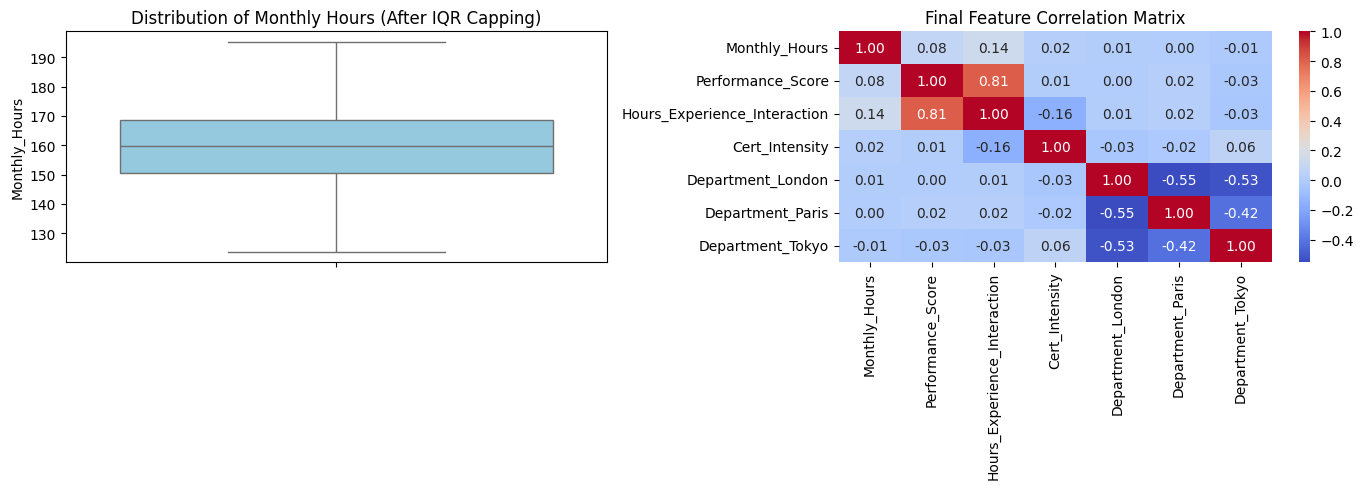

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up a clean plotting area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Verify Outlier Neutralization
sns.boxplot(data=df_final_production, y='Monthly_Hours', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Monthly Hours (After IQR Capping)')

# 2. Verify Collinearity Eradication (Heatmap)
sns.heatmap(df_final_production.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Final Feature Correlation Matrix')

plt.tight_layout()
plt.show()

In [11]:
# Save the final pristine production dataset to a CSV file
df_final_production.to_csv('decodelabs_project1_clean_output.csv', index=False)
print("Success! Your clean dataset has been saved as 'decodelabs_project1_clean_output.csv'.")

Success! Your clean dataset has been saved as 'decodelabs_project1_clean_output.csv'.
